In [135]:
# Allow imports from the parent directory
import sys
import os
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [136]:
# Imports
import torchvision
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from data.dataset import TouchFLDataset
import data.utils as utils

In [137]:
# Define dataset configuration parameters for splitting and normalisation
dataset_config = {
    'random_state': 52,
    'split_size': 0.30,
    'stratify_label': 'object',
    'transform_name': 'center_crop_224',  # Choose from 'pad_224', 'center_crop_224', 'random_crop_224'
    'bg_path': None,  # Not using background subtraction
}

### Load Data

In [138]:
# Load the dataset into a DataFrame
df = utils.load_touch_fl_dataset()
# Display the first few rows of the DataFrame
df.head(3)

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,materials,description,interaction_num,frame_num,interaction_id
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beans,base,beans_base,1,sliding,0.016114,0.013392,hard,metal,Metallic bottom surface with raised rim and sl...,0001,0001,beans_base_force1_interaction0001
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beans,base,beans_base,1,sliding,0.014502,0.012053,hard,metal,Metallic bottom surface with raised rim and sl...,0001,0002,beans_base_force1_interaction0001
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beans,base,beans_base,1,sliding,0.016114,0.013392,hard,metal,Metallic bottom surface with raised rim and sl...,0001,0003,beans_base_force1_interaction0001


In [139]:
# Split the dataset into training, validation, and test sets
# The split is done by interaction to ensure that all samples from a given interaction are in the same set to avoid data leakage
train_df, val_df, test_df = utils.split_by_interaction(
    df,
    split_size=dataset_config['split_size'],
    stratify_label=dataset_config['stratify_label'],
    random_state=dataset_config['random_state'])

Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800


In [140]:
# Get label information from the training set
label_info = utils.get_label_info(train_df)
label_info.keys()

dict_keys(['label2idx', 'idx2label', 'materials_list'])

In [141]:
# Extract the idx2label mappings from the label information
# This is so we can use them later to convert model predictions back to human-readable labels
idx2label = label_info['idx2label']
idx2label.keys()

dict_keys(['object', 'region', 'object_region', 'motion', 'hardness'])

In [142]:
# Extract the list of materials from the label information
materials_list = label_info['materials_list']
materials_list

['cardboard', 'felt', 'metal', 'paper', 'plastic', 'rubber', 'tissue paper']

In [143]:
# Get normalisation statistics from the training set for this dataset configuration
# If a cache file exists, it will be loaded instead of recomputing the statistics
norm_stats = utils.get_norm_stats(train_df, '../configs/norm_cache.json', dataset_config)
norm_stats

Norm cache found, loading normalisation stats.


(tensor([0.4306, 0.4631, 0.3769]), tensor([0.2092, 0.1563, 0.1222]))

### TouchFL Dataset

In [144]:
# Create dataset objects for the training set using the TouchFLDataset class
train_dataset = TouchFLDataset(train_df, 
                               label_info, 
                               dataset_config['transform_name'], 
                               norm_stats, 
                               dataset_config['bg_path'])

In [145]:
# Get a sample from the training dataset and display its keys to see what data is included in each sample
sample = train_dataset[0]
sample.keys()

dict_keys(['image', 'force_level', 'force_n', 'fsr_voltage', 'description', 'interaction_num', 'frame_num', 'interaction_id', 'materials', 'object', 'region', 'object_region', 'motion', 'hardness'])

In [146]:
# Display the shapes of the image tensor and the values of the other features in the sample
for k, v in sample.items():
    print(f"{k}: {v.shape if k == 'image' else v}")

image: torch.Size([3, 224, 224])
force_level: 1
force_n: 0.013392293825745583
fsr_voltage: 0.0161135271191597
description: Metallic bottom surface with raised rim and slightly recessed centre. The surface features concentric structural ridges and a smooth, cold finish.
interaction_num: 0001
frame_num: 0001
interaction_id: beans_base_force1_interaction0001
materials: tensor([0., 0., 1., 0., 0., 0., 0.])
object: 0
region: 0
object_region: 0
motion: 0
hardness: 0


In [147]:
# Use the idx2label mappings to convert the class indexes back to a human-readable class names
for k in idx2label.keys():
    mapping = idx2label[k]
    class_idx = sample[k].item()
    class_name = mapping[class_idx]
    print(f'{k}: {class_name} (class index: {class_idx})')

object: beans (class index: 0)
region: base (class index: 0)
object_region: beans_base (class index: 0)
motion: sliding (class index: 0)
hardness: hard (class index: 0)


In [148]:
# Decode the materials multi-hot vector back to a list of material names using the materials_list
active_materials = utils.decode_materials(sample['materials'], materials_list)
active_materials

['metal']

### Data Loader and Visualisation

In [149]:
# Create a small batch size dataloader for visualisation
viz_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
data = next(iter(viz_dataloader))

In [150]:
# Extract the inputs and object labels from the batch of data
inputs, labels = data['image'], data['object']
# Create a grid of the input images for visualisation using torchvision's make_grid function
grid = torchvision.utils.make_grid(inputs)

/tmp/ipykernel_26943/2492407880.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  input = std * input + mean


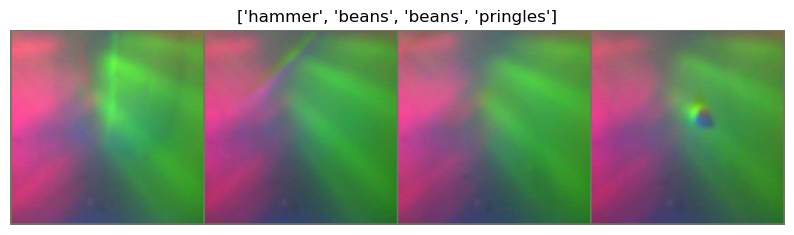

In [151]:
# Convert grid image tensor to a numpy array and transpose it to (H, W, C) format for plotting
input = grid.numpy().transpose((1, 2, 0))
# Un-normalise the image for correct display
mean = norm_stats[0]
std = norm_stats[1]
input = std * input + mean
input = np.clip(input, 0, 1)
# Display the image using matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(input)
plt.title([idx2label['object'][idx.item()] for idx in labels])
plt.axis('off')
plt.show()